In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python-Datasets/loan.csv')
df

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved
...,...,...,...,...,...,...,...,...
56,39,Male,Architect,Master's,Married,100000,770,Approved
57,25,Female,Receptionist,High School,Single,32000,570,Denied
58,43,Male,Banker,Bachelor's,Married,95000,760,Approved
59,30,Female,Writer,Master's,Single,55000,650,Approved


#EDA

In [ ]:
df.shape

(61, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              61 non-null     int64 
 1   gender           61 non-null     object
 2   occupation       61 non-null     object
 3   education_level  61 non-null     object
 4   marital_status   61 non-null     object
 5   income           61 non-null     int64 
 6   credit_score     61 non-null     int64 
 7   loan_status      61 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


In [ ]:
df.describe()

,age,income,credit_score
count,61.000000,61.000000,61.000000
mean,37.081967,78983.606557,709.836066
std,8.424755,33772.025802,72.674888
min,24.000000,25000.000000,560.000000
25%,30.000000,52000.000000,650.000000
50%,36.000000,78000.000000,720.000000
75%,43.000000,98000.000000,770.000000
max,55.000000,180000.000000,830.000000


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
occupation,0
education_level,0
marital_status,0
income,0
credit_score,0
loan_status,0


In [ ]:
df.columns

Index(['age', 'gender', 'occupation', 'education_level', 'marital_status',
       'income', 'credit_score', 'loan_status'],
      dtype='object')

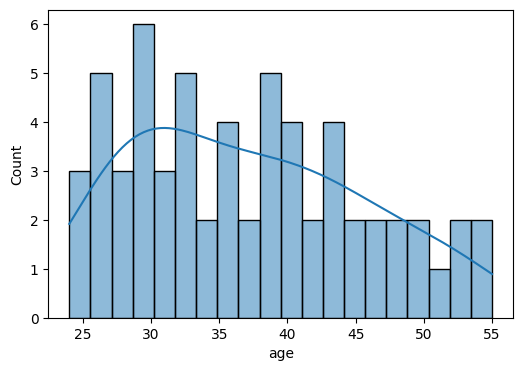

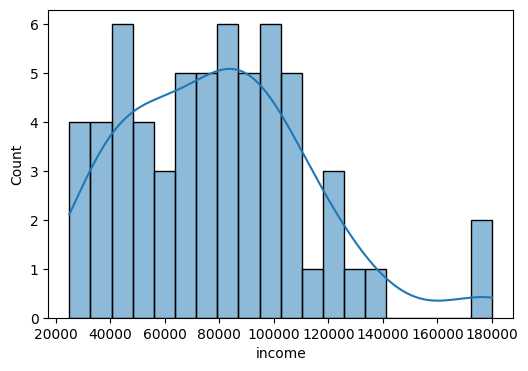

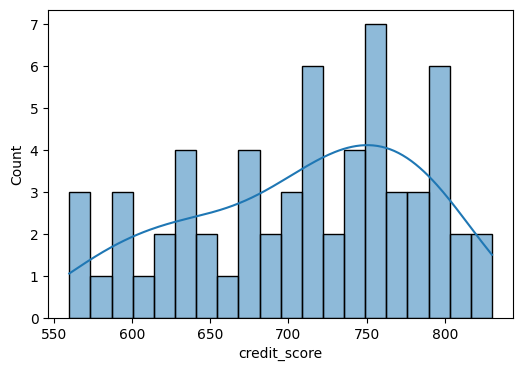

In [ ]:
numeric_columns = ['age', 'income', 'credit_score']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde = True , bins = 20)

<Axes: xlabel='gender', ylabel='count'>

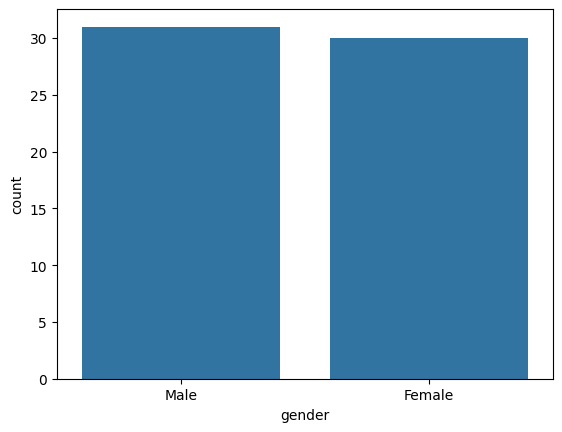

In [ ]:
sns.countplot(x = df['gender'])

<Axes: xlabel='education_level', ylabel='count'>

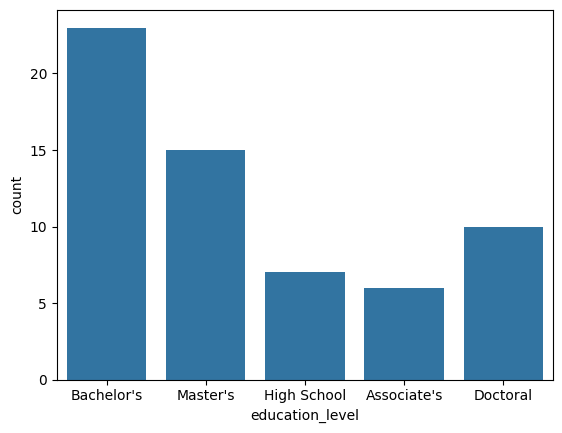

In [ ]:
sns.countplot(x = df["education_level"])

<Axes: xlabel='loan_status', ylabel='count'>

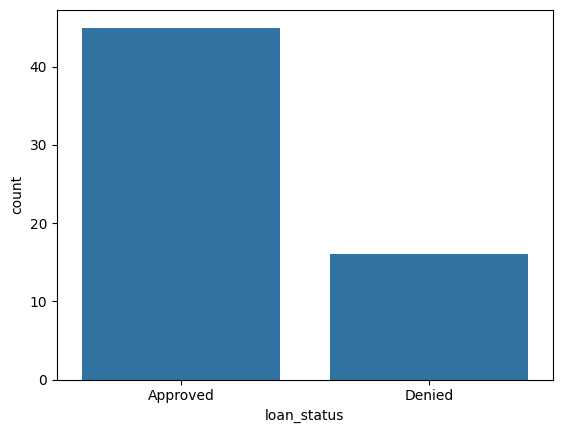

In [ ]:
sns.countplot(x = df["loan_status"])

# Data Cleaning and preprocessing

In [ ]:
df_cleaned = df.copy()

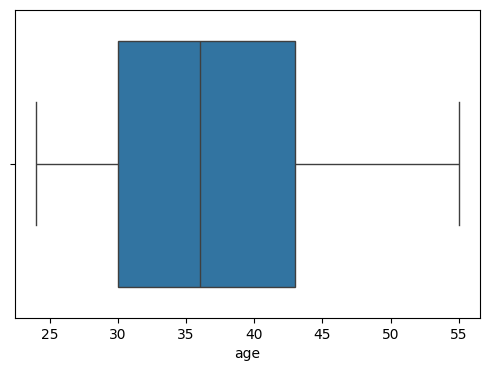

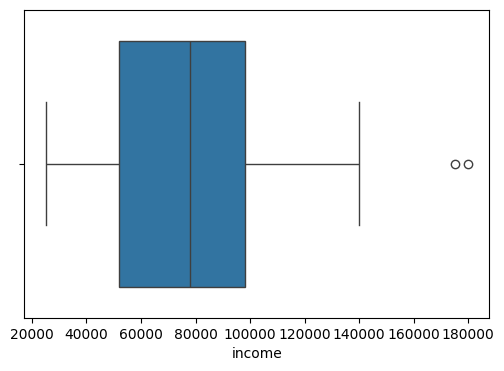

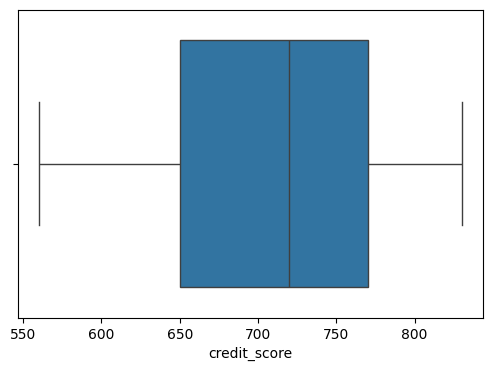

In [ ]:
for col in numeric_columns:
  plt.figure(figsize = (6, 4))
  sns.boxplot(x = df_cleaned[col])

<Axes: >

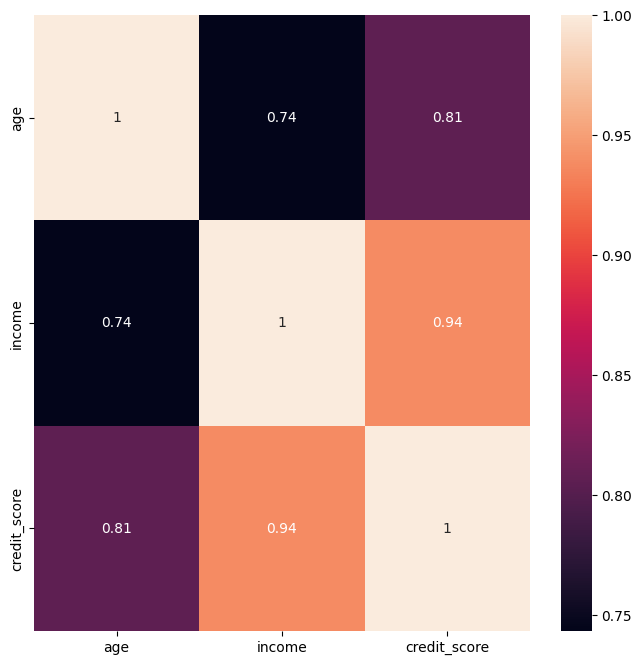

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(df.corr(numeric_only=True), annot = True)

In [ ]:
df_cleaned.head()

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved


In [ ]:
df_cleaned.drop_duplicates(inplace = True)

In [ ]:
df_cleaned.shape

(61, 8)

In [ ]:
df_cleaned.isnull().sum()

,0
age,0
gender,0
occupation,0
education_level,0
marital_status,0
income,0
credit_score,0
loan_status,0


In [ ]:
df_cleaned.dtypes

,0
age,int64
gender,object
occupation,object
education_level,object
marital_status,object
income,int64
credit_score,int64
loan_status,object


In [ ]:
df_cleaned['gender'].value_counts()
df_cleaned['marital_status'].value_counts()
df_cleaned['loan_status'].value_counts()

,count
loan_status,
Approved,45
Denied,16


In [ ]:
df_cleaned['gender'] = df_cleaned['gender'].map({"Male" : 0,"Female" : 1})
df_cleaned['marital_status'] = df_cleaned['marital_status'].map({"Single" : 0,"Married" : 1})
df_cleaned['loan_status'] = df_cleaned['loan_status'].map({"Denied" : 0,"Approved" : 1})

In [ ]:
df_cleaned

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,0,Engineer,Bachelor's,1,85000,720,1
1,45,1,Teacher,Master's,0,62000,680,1
2,28,0,Student,High School,0,25000,590,0
3,51,1,Manager,Bachelor's,1,105000,780,1
4,36,0,Accountant,Bachelor's,1,75000,710,1
...,...,...,...,...,...,...,...,...
56,39,0,Architect,Master's,1,100000,770,1
57,25,1,Receptionist,High School,0,32000,570,0
58,43,0,Banker,Bachelor's,1,95000,760,1
59,30,1,Writer,Master's,0,55000,650,1


In [ ]:
 df_cleaned.rename(columns={"gender": "is_female",
                          'marital_status': "is_married",
                           'loan_status': "is_approved",
                          }, inplace = True)

In [ ]:
df_cleaned

,age,is_female,occupation,education_level,is_married,income,credit_score,is_approved
0,32,0,Engineer,Bachelor's,1,85000,720,1
1,45,1,Teacher,Master's,0,62000,680,1
2,28,0,Student,High School,0,25000,590,0
3,51,1,Manager,Bachelor's,1,105000,780,1
4,36,0,Accountant,Bachelor's,1,75000,710,1
...,...,...,...,...,...,...,...,...
56,39,0,Architect,Master's,1,100000,770,1
57,25,1,Receptionist,High School,0,32000,570,0
58,43,0,Banker,Bachelor's,1,95000,760,1
59,30,1,Writer,Master's,0,55000,650,1


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['education_level'], drop_first=True)
df_cleaned = pd.get_dummies(df_cleaned, columns = ['occupation'], drop_first=True)

In [ ]:
df['education_level'].value_counts()

,count
education_level,
Bachelor's,23
Master's,15
Doctoral,10
High School,7
Associate's,6


In [ ]:
df_cleaned

,age,is_female,is_married,income,credit_score,is_approved,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,...,occupation_Researcher,occupation_Sales,occupation_Salesman,occupation_Server,occupation_Software,occupation_Student,occupation_Stylist,occupation_Teacher,occupation_Veterinarian,occupation_Writer
0,32,0,1,85000,720,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,45,1,0,62000,680,1,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,28,0,0,25000,590,0,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,51,1,1,105000,780,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,36,0,1,75000,710,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,39,0,1,100000,770,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
57,25,1,0,32000,570,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
58,43,0,1,95000,760,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59,30,1,0,55000,650,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned

,age,is_female,is_married,income,credit_score,is_approved,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,...,occupation_Researcher,occupation_Sales,occupation_Salesman,occupation_Server,occupation_Software,occupation_Student,occupation_Stylist,occupation_Teacher,occupation_Veterinarian,occupation_Writer
0,32,0,1,85000,720,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,45,1,0,62000,680,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,28,0,0,25000,590,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,51,1,1,105000,780,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,36,0,1,75000,710,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,39,0,1,100000,770,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
57,25,1,0,32000,570,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
58,43,0,1,95000,760,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59,30,1,0,55000,650,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


# Feature Engineering and Extraction


In [ ]:
df_cleaned.columns

Index(['age', 'is_female', 'is_married', 'income', 'credit_score',
       'is_approved', 'education_level_Bachelor's', 'education_level_Doctoral',
       'education_level_High School', 'education_level_Master's',
       'occupation_Analyst', 'occupation_Architect', 'occupation_Artist',
       'occupation_Banker', 'occupation_Chef', 'occupation_Consultant',
       'occupation_Dentist', 'occupation_Designer', 'occupation_Doctor',
       'occupation_Editor', 'occupation_Electrician', 'occupation_Engineer',
       'occupation_HR', 'occupation_IT', 'occupation_Lawyer',
       'occupation_Manager', 'occupation_Marketing', 'occupation_Musician',
       'occupation_Nurse', 'occupation_Pharmacist', 'occupation_Photographer',
       'occupation_Pilot', 'occupation_Professor', 'occupation_Programmer',
       'occupation_Psychologist', 'occupation_Realtor',
       'occupation_Receptionist', 'occupation_Researcher', 'occupation_Sales',
       'occupation_Salesman', 'occupation_Server', 'occupation_

In [ ]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'income']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [ ]:
df_cleaned.head()

,age,is_female,is_married,income,credit_score,is_approved,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,...,occupation_Researcher,occupation_Sales,occupation_Salesman,occupation_Server,occupation_Software,occupation_Student,occupation_Stylist,occupation_Teacher,occupation_Veterinarian,occupation_Writer
0,-0.608224,0,1,0.179626,720,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.947653,1,0,-0.507063,680,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,-1.086956,0,0,-1.611737,590,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,1.665750,1,1,0.776746,780,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-0.129493,0,1,-0.118935,710,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from scipy.stats import pearsonr

selected_features = ['age', 'is_female', 'is_married', 'income', 'credit_score',
       'is_approved', "education_level_Bachelor's", "education_level_Doctoral",
       'education_level_High School', "education_level_Master's",
       'occupation_Analyst', 'occupation_Architect', 'occupation_Artist',
       'occupation_Banker', 'occupation_Chef', 'occupation_Consultant',
       'occupation_Dentist', 'occupation_Designer', 'occupation_Doctor',
       'occupation_Editor', 'occupation_Electrician', 'occupation_Engineer',
       'occupation_HR', 'occupation_IT', 'occupation_Lawyer',
       'occupation_Manager', 'occupation_Marketing', 'occupation_Musician',
       'occupation_Nurse', 'occupation_Pharmacist', 'occupation_Photographer',
       'occupation_Pilot', 'occupation_Professor', 'occupation_Programmer',
       'occupation_Psychologist', 'occupation_Realtor',
       'occupation_Receptionist', 'occupation_Researcher', 'occupation_Sales',
       'occupation_Salesman', 'occupation_Server', 'occupation_Software',
       'occupation_Student', 'occupation_Stylist', 'occupation_Teacher',
       'occupation_Veterinarian', 'occupation_Writer']

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['credit_score'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,credit_score,1.000000
3,income,0.937983
2,is_married,0.845532
5,is_approved,0.820765
0,age,0.806042
7,education_level_Doctoral,0.529353
18,occupation_Doctor,0.294178
32,occupation_Professor,0.230317
24,occupation_Lawyer,0.217545
9,education_level_Master's,0.212570


In [ ]:
cat_features = ['is_female', 'is_married', 'is_approved', "education_level_Bachelor's", "education_level_Doctoral",
       'education_level_High School', "education_level_Master's",
       'occupation_Analyst', 'occupation_Architect', 'occupation_Artist',
       'occupation_Banker', 'occupation_Chef', 'occupation_Consultant',
       'occupation_Dentist', 'occupation_Designer', 'occupation_Doctor',
       'occupation_Editor', 'occupation_Electrician', 'occupation_Engineer',
       'occupation_HR', 'occupation_IT', 'occupation_Lawyer',
       'occupation_Manager', 'occupation_Marketing', 'occupation_Musician',
       'occupation_Nurse', 'occupation_Pharmacist', 'occupation_Photographer',
       'occupation_Pilot', 'occupation_Professor', 'occupation_Programmer',
       'occupation_Psychologist', 'occupation_Realtor',
       'occupation_Receptionist', 'occupation_Researcher', 'occupation_Sales',
       'occupation_Salesman', 'occupation_Server', 'occupation_Software',
       'occupation_Student', 'occupation_Stylist', 'occupation_Teacher',
       'occupation_Veterinarian', 'occupation_Writer']

In [ ]:
# Chi Square test (DO AGAIN)

In [ ]:
df_cleaned['credit_score_bin'] = pd.cut(df_cleaned['credit_score'], bins=3, labels=['Low', 'Medium', 'High'])

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

cat_features = ['is_female', 'is_married', 'is_approved', "education_level_Bachelor's", "education_level_Doctoral",
       'education_level_High School', "education_level_Master's",
       'occupation_Analyst', 'occupation_Architect', 'occupation_Artist',
       'occupation_Banker', 'occupation_Chef', 'occupation_Consultant',
       'occupation_Dentist', 'occupation_Designer', 'occupation_Doctor',
       'occupation_Editor', 'occupation_Electrician', 'occupation_Engineer',
       'occupation_HR', 'occupation_IT', 'occupation_Lawyer',
       'occupation_Manager', 'occupation_Marketing', 'occupation_Musician',
       'occupation_Nurse', 'occupation_Pharmacist', 'occupation_Photographer',
       'occupation_Pilot', 'occupation_Professor', 'occupation_Programmer',
       'occupation_Psychologist', 'occupation_Realtor',
       'occupation_Receptionist', 'occupation_Researcher', 'occupation_Sales',
       'occupation_Salesman', 'occupation_Server', 'occupation_Software',
       'occupation_Student', 'occupation_Stylist', 'occupation_Teacher',
       'occupation_Veterinarian', 'occupation_Writer']

chi2_results = {}

for col in cat_features:
    # Ensure we don't try to compare credit_score_bin with itself if it somehow got into cat_features
    if col != 'credit_score_bin':
        contingency = pd.crosstab(df_cleaned[col], df_cleaned['credit_score_bin'])
        # Perform Chi-square test only if the contingency table is not empty
        if not contingency.empty and contingency.sum().sum() > 0:
            chi2_stat, p_val, _, _ = chi2_contingency(contingency)
            decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
            chi2_results[col] = {
                'chi2_statistic': chi2_stat,
                'p_value': p_val,
                'Decision': decision
            }
        else:
            chi2_results[col] = {
                'chi2_statistic': float('nan'),
                'p_value': float('nan'),
                'Decision': 'Not enough data for test'
            }

chi2_df = pd.DataFrame(chi2_results).T
display(chi2_df.sort_values(by='p_value'))

print('\nInterpretation: Lower P-value indicates a stronger association between the categorical feature and credit_score_bin. A \'Reject Null\' decision suggests the feature is statistically significant for distinguishing credit score bins.')

,chi2_statistic,p_value,Decision
is_approved,51.221804,0.0,Reject Null (Keep Feature)
is_married,39.667486,0.0,Reject Null (Keep Feature)
education_level_High School,14.688853,0.000646,Reject Null (Keep Feature)
education_level_Doctoral,14.065741,0.000882,Reject Null (Keep Feature)
occupation_Writer,5.815678,0.054594,Accept Null (Drop Feature)
occupation_Designer,5.815678,0.054594,Accept Null (Drop Feature)
occupation_Receptionist,5.815678,0.054594,Accept Null (Drop Feature)
occupation_Artist,5.815678,0.054594,Accept Null (Drop Feature)
occupation_Salesman,5.815678,0.054594,Accept Null (Drop Feature)
education_level_Master's,5.565743,0.061861,Accept Null (Drop Feature)



Interpretation: Lower P-value indicates a stronger association between the categorical feature and credit_score_bin. A 'Reject Null' decision suggests the feature is statistically significant for distinguishing credit score bins.


In [ ]:
df_cleaned['age_bin'] = pd.qcut(df_cleaned['age'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df_cleaned['income_bin'] = pd.qcut(df_cleaned['income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

display(df_cleaned[['age', 'age_bin', 'income', 'income_bin']].head())

,age,age_bin,income,income_bin
0,-0.608224,Q2,0.179626,Q3
1,0.947653,Q4,-0.507063,Q2
2,-1.086956,Q1,-1.611737,Q1
3,1.665750,Q4,0.776746,Q4
4,-0.129493,Q2,-0.118935,Q2


### Applying One-Hot Encoding to binned `age` and `income`

To align with the `insurance.csv` example, we'll convert the `age_bin` and `income_bin` categorical columns into multiple binary (0/1) columns using `pd.get_dummies`. We'll also drop the first dummy variable to avoid multicollinearity.

In [ ]:
# Apply one-hot encoding to age_bin and income_bin
df_cleaned = pd.get_dummies(df_cleaned, columns=['age_bin', 'income_bin'], drop_first=True)

# Convert the new dummy columns to integer type
# Identify newly created dummy columns
new_age_bin_cols = [col for col in df_cleaned.columns if col.startswith('age_bin_')]
new_income_bin_cols = [col for col in df_cleaned.columns if col.startswith('income_bin_')]

for col in new_age_bin_cols + new_income_bin_cols:
    df_cleaned[col] = df_cleaned[col].astype(int)

display(df_cleaned.head())

,age,is_female,is_married,income,credit_score,is_approved,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,...,occupation_Teacher,occupation_Veterinarian,occupation_Writer,credit_score_bin,age_bin_Q2,age_bin_Q3,age_bin_Q4,income_bin_Q2,income_bin_Q3,income_bin_Q4
0,-0.608224,0,1,0.179626,720,1,1,0,0,0,...,0,0,0,Medium,1,0,0,0,1,0
1,0.947653,1,0,-0.507063,680,1,0,0,0,1,...,1,0,0,Medium,0,0,1,1,0,0
2,-1.086956,0,0,-1.611737,590,0,0,0,1,0,...,0,0,0,Low,0,0,0,0,0,0
3,1.665750,1,1,0.776746,780,1,1,0,0,0,...,0,0,0,High,0,0,1,0,0,1
4,-0.129493,0,1,-0.118935,710,1,1,0,0,0,...,0,0,0,Medium,1,0,0,1,0,0


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Get all one-hot encoded age_bin and income_bin columns
age_bin_dummy_cols = [col for col in df_cleaned.columns if col.startswith('age_bin_')]
income_bin_dummy_cols = [col for col in df_cleaned.columns if col.startswith('income_bin_')]

# Update the list of categorical features to include the new one-hot encoded variables
cat_features_updated = [
    'is_female', 'is_married', 'is_approved',
    "education_level_Bachelor's", "education_level_Doctoral",
    'education_level_High School', "education_level_Master's",
    'occupation_Analyst', 'occupation_Architect', 'occupation_Artist',
    'occupation_Banker', 'occupation_Chef', 'occupation_Consultant',
    'occupation_Dentist', 'occupation_Designer', 'occupation_Doctor',
    'occupation_Editor', 'occupation_Electrician', 'occupation_Engineer',
    'occupation_HR', 'occupation_IT', 'occupation_Lawyer',
    'occupation_Manager', 'occupation_Marketing', 'occupation_Musician',
    'occupation_Nurse', 'occupation_Pharmacist', 'occupation_Photographer',
    'occupation_Pilot', 'occupation_Professor', 'occupation_Programmer',
    'occupation_Psychologist', 'occupation_Realtor',
    'occupation_Receptionist', 'occupation_Researcher', 'occupation_Sales',
    'occupation_Salesman', 'occupation_Server', 'occupation_Software',
    'occupation_Student', 'occupation_Stylist', 'occupation_Teacher',
    'occupation_Veterinarian', 'occupation_Writer',
] + age_bin_dummy_cols + income_bin_dummy_cols # Added one-hot encoded age and income

chi2_results_updated = {}

for col in cat_features_updated:
    if col != 'credit_score_bin':
        contingency = pd.crosstab(df_cleaned[col], df_cleaned['credit_score_bin'])
        if not contingency.empty and contingency.sum().sum() > 0:
            # Ensure that the categories in the contingency table are not empty
            # This check might be redundant after `drop_first=True` and `astype(int)`
            # but good for robustness.
            if contingency.sum().min() > 0 and contingency.sum(axis=1).min() > 0:
                chi2_stat, p_val, _, _ = chi2_contingency(contingency)
                decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
                chi2_results_updated[col] = {
                    'chi2_statistic': chi2_stat,
                    'p_value': p_val,
                    'Decision': decision
                }
            else:
                chi2_results_updated[col] = {
                    'chi2_statistic': float('nan'),
                    'p_value': float('nan'),
                    'Decision': 'Not enough data or single category in contingency table'
                }
        else:
            chi2_results_updated[col] = {
                'chi2_statistic': float('nan'),
                'p_value': float('nan'),
                'Decision': 'Contingency table is empty'
            }

chi2_df_updated = pd.DataFrame(chi2_results_updated).T
display(chi2_df_updated.sort_values(by='p_value'))

print('\nInterpretation: Lower P-value indicates a stronger association between the categorical feature and credit_score_bin. A \'Reject Null\' decision suggests the feature is statistically significant for distinguishing credit score bins.')

,chi2_statistic,p_value,Decision
is_approved,51.221804,0.0,Reject Null (Keep Feature)
is_married,39.667486,0.0,Reject Null (Keep Feature)
income_bin_Q4,32.863894,0.0,Reject Null (Keep Feature)
income_bin_Q2,28.490275,0.000001,Reject Null (Keep Feature)
age_bin_Q4,16.078149,0.000323,Reject Null (Keep Feature)
education_level_High School,14.688853,0.000646,Reject Null (Keep Feature)
education_level_Doctoral,14.065741,0.000882,Reject Null (Keep Feature)
age_bin_Q3,7.925073,0.019015,Reject Null (Keep Feature)
income_bin_Q3,7.125752,0.028357,Reject Null (Keep Feature)
age_bin_Q2,6.814952,0.033125,Reject Null (Keep Feature)



Interpretation: Lower P-value indicates a stronger association between the categorical feature and credit_score_bin. A 'Reject Null' decision suggests the feature is statistically significant for distinguishing credit score bins.


In [ ]:
significant_features = chi2_df_updated[chi2_df_updated['Decision'] == 'Reject Null (Keep Feature)'].index.tolist()


if 'credit_score_bin' in significant_features:
    significant_features.remove('credit_score_bin')


significant_features.append('credit_score')


final_df = df_cleaned[significant_features]

display(final_df.head())
display(final_df.shape)

,is_married,is_approved,education_level_Doctoral,education_level_High School,age_bin_Q2,age_bin_Q3,age_bin_Q4,income_bin_Q2,income_bin_Q3,income_bin_Q4,credit_score
0,1,1,0,0,1,0,0,0,1,0,720
1,0,1,0,0,0,0,1,1,0,0,680
2,0,0,0,1,0,0,0,0,0,0,590
3,1,1,0,0,0,0,1,0,0,1,780
4,1,1,0,0,1,0,0,1,0,0,710


(61, 11)